In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from pandas.plotting import andrews_curves

dataset=pd.read_csv(r"./DATASET/Titanic.csv")


In [3]:
dataset.head(33)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
dataset.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q
891,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
892,999,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


In [5]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          689
Embarked         2
dtype: int64

In [6]:
dataset.duplicated().sum()

np.int64(1)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  893 non-null    int64  
 1   Survived     893 non-null    int64  
 2   Pclass       893 non-null    int64  
 3   Name         893 non-null    object 
 4   Sex          893 non-null    object 
 5   Age          716 non-null    float64
 6   SibSp        893 non-null    int64  
 7   Parch        893 non-null    int64  
 8   Ticket       893 non-null    object 
 9   Fare         893 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.8+ KB


In [8]:
median_age=dataset['Age'].median()
dataset['Age']=dataset['Age'].fillna(median_age)

dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,447.106383,0.384099,2.309071,29.345095,0.521837,0.381859,32.170039
std,258.139972,0.486654,0.835518,13.010528,1.101784,0.805521,49.644782
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,447.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,670.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,999.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
dataset.shape

(893, 12)

In [10]:
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [41]:
numerical_data=dataset.drop(columns=['PassengerId','Cabin','Embarked','Name','Ticket'])

In [42]:
numerical_data['Sex']=numerical_data['Sex'].map({"male":0,"female":1})

In [48]:
numerical_data.head(7)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500
5,0,3,0,28.0,0,0,8.4583
6,0,1,0,54.0,0,0,51.8625


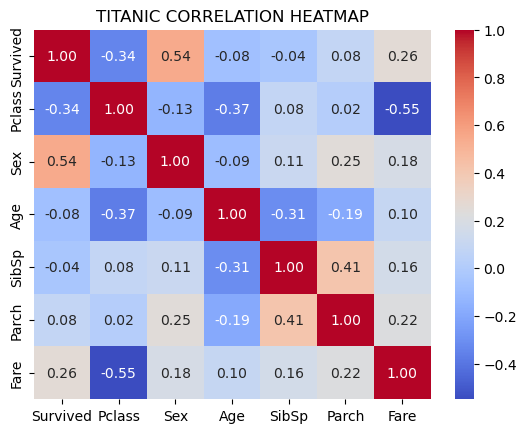

In [34]:
corr=numerical_data.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("TITANIC CORRELATION HEATMAP")
plt.show()

In [44]:
dataset['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [47]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
numerical_data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

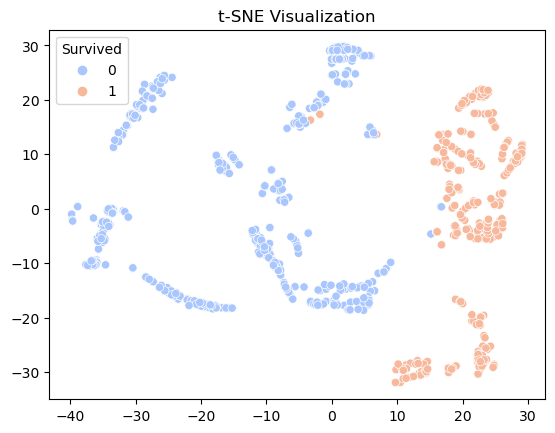

In [66]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(numerical_data)
tsne=TSNE(n_components=2,random_state=42)
tsne_results=tsne.fit_transform(scaled_data)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1],hue=numerical_data['Survived'], palette='coolwarm')
plt.title('t-SNE Visualization')
plt.show()

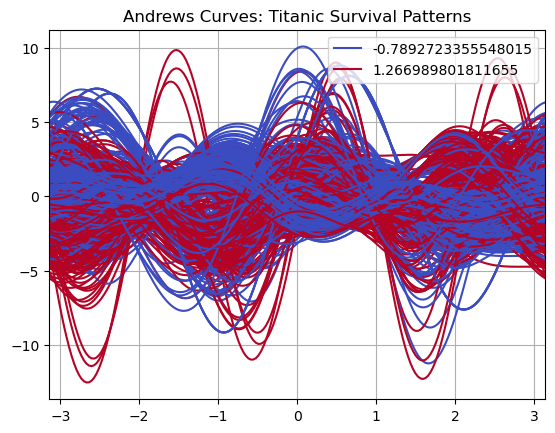

In [67]:



data_scaled = pd.DataFrame(scaler.fit_transform(numerical_data), columns=numerical_data.columns)

andrews_curves(data_scaled, 'Survived', colormap='coolwarm')

plt.title('Andrews Curves: Titanic Survival Patterns')
plt.show()

In [58]:
numerical_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


In [10]:
dataset.duplicated().sum()

1